### Cell 1 — Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append("../backend")
from nllb_translator import nllb_translate
try:
    from deep_translator import GoogleTranslator
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install deep-translator -q
    from deep_translator import GoogleTranslator
import sacrebleu


### Cell 2 — Load Corpus & Sample 50 Reference Pairs

In [9]:
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
CORPUS_PATH = os.path.join(
    ROOT,
    'backend',
    'data',
    'medical_corpus.csv'
)

df_corpus = pd.read_csv(CORPUS_PATH)

print(f"Total pairs in corpus: {len(df_corpus)}")
print(f"Columns: {df_corpus.columns.tolist()}")


Total pairs in corpus: 5000
Columns: ['sentence_id', 'domain_category', 'english_text', 'sesotho_text', 'source', 'source_reference', 'translator_code', 'reviewer_status', 'notes']


### Cell 3 — Sample & Exclude Previously Evaluated Sentences

In [12]:
# Adjust to match your actual column names
ENGLISH_COL = "english_text"
SESOTHO_COL = "sesotho_text"

# Load the 10 sentences already used in human evaluation
already_evaluated = [
    "Continue taking your ARVs every day without missing a dose.",
    "HIV is managed with antiretroviral therapy taken daily.",
    "Complete the full course of TB treatment even if you feel better.",
    "Tuberculosis is spread through the air when an infected person coughs.",
    "Take one tablet twice daily after meals.",
    "Do not stop taking this medicine without consulting your doctor.",
    "If you experience chest pain or difficulty breathing, seek help immediately.",
    "Please attend your follow-up appointment next week.",
    "Attend all antenatal care visits during your pregnancy.",
    "Wash your hands regularly to prevent the spread of infection.",
]

df_pool = (
    df_corpus[[ENGLISH_COL, SESOTHO_COL]]
    .dropna()
    .rename(columns={ENGLISH_COL: "english", SESOTHO_COL: "reference_sesotho"})
)

# Exclude already-evaluated sentences
df_pool = df_pool[~df_pool["english"].isin(already_evaluated)]

# Sample 50 held-out pairs
df_ref = df_pool.sample(n=50, random_state=42).reset_index(drop=True)

print(f" Sampled {len(df_ref)} held-out reference pairs")
print(f"   (excluded {len(already_evaluated)} previously evaluated sentences)")
print(df_ref.head(3))


 Sampled 50 held-out reference pairs
   (excluded 10 previously evaluated sentences)
                                             english  \
0  I am proud that I never missed a single dose o...   
1  Set a daily alarm on your phone to remind you ...   
2  Take your medicine with a commitment to comple...   

                                   reference_sesotho  
0  Ke ikantse hore ha ke eso lahleheloe ke dose l...  
1  Beha alarm ea letsatsi le leng le le leng moha...  
2  Nka moriana oa hau le boikarabello ba ho phete...  


### Cell 4 — Generate NLLB-200 Translations

In [13]:
nllb_outputs = []

print("Translating with NLLB-200...\n")
for i, row in df_ref.iterrows():
    result = nllb_translate(row["english"], src="english", tgt="sesotho")
    nllb_outputs.append(result)
    print(f"  [{i+1}/50] {result}")

df_ref["nllb_sesotho"] = nllb_outputs
print("\n NLLB-200 done")


Translating with NLLB-200...

Loading NLLB-200 model from: facebook/nllb-200-distilled-600M
  (local model not found — downloading ~2.5GB from HuggingFace, please wait)
NLLB-200 loaded and ready.
  [1/50] Ke motlotlo hore ebe ha ho mohla nkileng ka fetoa ke meriana ea ka ea TB.
  [2/50] Beha alamo ea letsatsi le letsatsi fonong ea hao ho u hopotsa hore u noe meriana ea hao.
  [3/50] Nka meriana ea hao u ikemiselitse ho e sebelisa ka ho feletseng.
  [4/50] Motho e mong le e mong ea nang le ho khohlela ho tšoarellang ka nako e fetang libeke tse peli o lokela ho hlahlojoa hore na o na le TB.
  [5/50] Acyclovir e sebelisetsoa ho phekola herpes zoster ho batho ba nang le HIV.
  [6/50] Lebollo la bongaka la banna la boithatelo le fokotsa kotsi ea ho tšoaetsoa ke HIV ho banna.
  [7/50] Lobola le mekhoa e meng ea setso ka linako tse ling e ka eketsa kotsi ea HIV 'me e lokela ho tšohloa ka bolokolohi.
  [8/50] Nka lethal dose le lahlehileng kapele kamoo ho ka khonehang, 'me u tsoele pele ho lat

### Cell 5 — Generate Google Translate Translations

In [16]:
google_outputs = []

print("Translating with Google Translate...\n")
for i, row in df_ref.iterrows():
    result = GoogleTranslator(source="en", target="st").translate(row["english"])
    google_outputs.append(result)
    print(f"  [{i+1}/50] {result}")

df_ref["google_sesotho"] = google_outputs
print("\n Google Translate done")


Translating with Google Translate...

  [1/50] Ke motlotlo hore ebe ha ho mohla nkileng ka fetoa ke lethal dose le le leng la moriana oa ka oa lefuba.
  [2/50] Beha alamo ea letsatsi le letsatsi fonong ea hau ho u hopotsa ho noa moriana oa hau.
  [3/50] Nka meriana ea hau ka boitlamo ba ho phethela thupelo e felletseng.
  [4/50] Mang kapa mang ea nang le khohlela e nkang nako e fetang libeke tse peli o lokela ho hlahlojoa hore na a na le lefuba.
  [5/50] Acyclovir e sebelisoa ho phekola herpes zoster ho batho ba phelang le HIV.
  [6/50] Lebollo la banna ka boithaopo le fokotsa kotsi ea HIV ho banna.
  [7/50] Lobola le litloaelo tse ling tsa setso ka linako tse ling li ka eketsa kotsi ea HIV 'me li hloka ho buisanoa ka bolokolohi.
  [8/50] Nka tekanyo e hlolohetsoeng kapele kamoo ho ka khonehang, 'me u tsoele pele joalokaha u laetsoe ke ngaka ea hau.
  [9/50] Haeba u fetoa ke tekanyetso, sebelisa mohlophisi oa lipilisi ho u thusa ho hopola nakong e tlang.
  [10/50] Thuto ea sechaba e fo

### Cell 6 — Corpus-Level Metrics Against Human Reference

In [17]:
references  = df_ref["reference_sesotho"].tolist()
nllb_hyps   = df_ref["nllb_sesotho"].tolist()
google_hyps = df_ref["google_sesotho"].tolist()

#  BLEU 
bleu_nllb   = sacrebleu.corpus_bleu(nllb_hyps,   [references])
bleu_google = sacrebleu.corpus_bleu(google_hyps, [references])

#  chrF++ 
chrf_nllb   = sacrebleu.corpus_chrf(nllb_hyps,   [references], word_order=2)
chrf_google = sacrebleu.corpus_chrf(google_hyps, [references], word_order=2)

#  TER 
ter_nllb    = sacrebleu.corpus_ter(nllb_hyps,   [references])
ter_google  = sacrebleu.corpus_ter(google_hyps, [references])

print("=" * 60)
print("   AUTOMATIC METRICS vs HUMAN REFERENCE (n=50)")
print("   Higher BLEU & chrF++ = better | Lower TER = better")
print("=" * 60)
print(f"  {'Model':<22} {'BLEU':>7} {'chrF++':>8} {'TER':>7}")
print("-" * 60)
print(f"  {'NLLB-200':<22} {bleu_nllb.score:>7.2f} {chrf_nllb.score:>8.2f} {ter_nllb.score:>7.2f}")
print(f"  {'Google Translate':<22} {bleu_google.score:>7.2f} {chrf_google.score:>8.2f} {ter_google.score:>7.2f}")
print("=" * 60)

#  Interpretation 
bleu_diff = bleu_nllb.score - bleu_google.score
chrf_diff = chrf_nllb.score - chrf_google.score
ter_diff  = ter_google.score - ter_nllb.score   # positive = NLLB has lower TER

print(f"""
Interpretation:
  NLLB-200 achieved a BLEU score of {bleu_nllb.score:.2f} compared to
  {bleu_google.score:.2f} for Google Translate — a {abs(bleu_diff):.2f}-point
  {'improvement' if bleu_diff > 0 else 'deficit'} suggesting
  {'better' if bleu_diff > 0 else 'weaker'} alignment with domain-specific
  medical reference translations.

  chrF++ scores of {chrf_nllb.score:.2f} (NLLB) vs {chrf_google.score:.2f} (Google)
  confirm this trend at the character n-gram level, which is particularly
  relevant for morphologically rich languages like Sesotho.

  TER scores of {ter_nllb.score:.2f} (NLLB) vs {ter_google.score:.2f} (Google)
  indicate that {'NLLB requires fewer edits' if ter_diff > 0 else 'Google requires fewer edits'}
  to match the human reference.
""")


   AUTOMATIC METRICS vs HUMAN REFERENCE (n=50)
   Higher BLEU & chrF++ = better | Lower TER = better
  Model                     BLEU   chrF++     TER
------------------------------------------------------------
  NLLB-200                 24.96    47.72   64.32
  Google Translate         28.11    48.64   57.53

Interpretation:
  NLLB-200 achieved a BLEU score of 24.96 compared to
  28.11 for Google Translate — a 3.15-point
  deficit suggesting
  weaker alignment with domain-specific
  medical reference translations.

  chrF++ scores of 47.72 (NLLB) vs 48.64 (Google)
  confirm this trend at the character n-gram level, which is particularly
  relevant for morphologically rich languages like Sesotho.

  TER scores of 64.32 (NLLB) vs 57.53 (Google)
  indicate that Google requires fewer edits
  to match the human reference.



### Cell 7 — Figure 7a: BLEU & chrF++ Chart (Higher is Better)

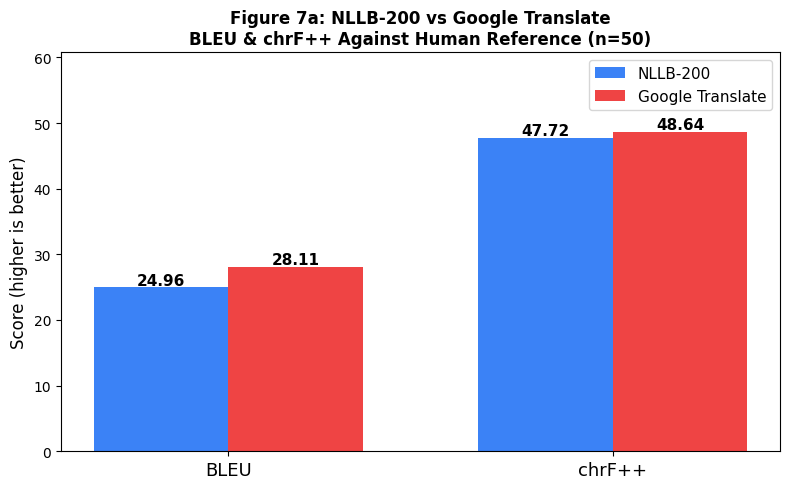

 Saved → figure7a_bleu_chrf.png


In [18]:
metrics     = ["BLEU", "chrF++"]
nllb_vals   = [bleu_nllb.score,   chrf_nllb.score]
google_vals = [bleu_google.score, chrf_google.score]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, nllb_vals,   width, label="NLLB-200",        color="#3b82f6")
bars2 = ax.bar(x + width/2, google_vals, width, label="Google Translate", color="#ef4444")

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=13)
ax.set_ylabel("Score (higher is better)", fontsize=12)
ax.set_ylim(0, max(nllb_vals + google_vals) * 1.25)
ax.set_title(
    "Figure 7a: NLLB-200 vs Google Translate\n"
    "BLEU & chrF++ Against Human Reference (n=50)",
    fontweight="bold", fontsize=12
)
ax.legend(fontsize=11)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f"{bar.get_height():.2f}",
            ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("figure7a_bleu_chrf.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved → figure7a_bleu_chrf.png")


### Cell 8 — Figure 7b: TER Chart (Lower is Better)

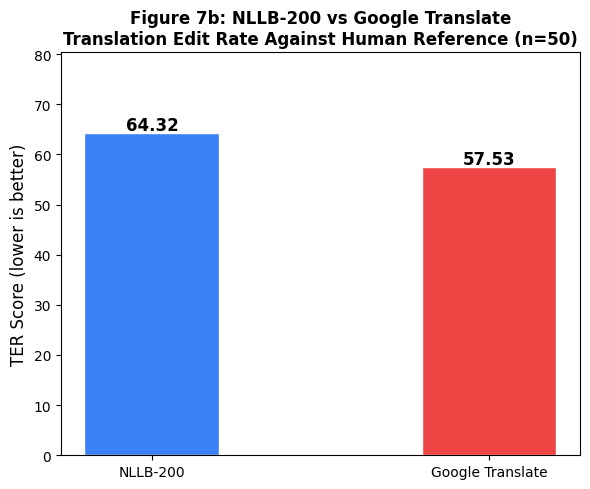

 Saved → figure7b_ter.png


In [19]:
models    = ["NLLB-200", "Google Translate"]
ter_vals  = [ter_nllb.score, ter_google.score]
colors    = ["#3b82f6", "#ef4444"]

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(models, ter_vals, color=colors, width=0.4, edgecolor="white")
ax.set_ylabel("TER Score (lower is better)", fontsize=12)
ax.set_ylim(0, max(ter_vals) * 1.25)
ax.set_title(
    "Figure 7b: NLLB-200 vs Google Translate\n"
    "Translation Edit Rate Against Human Reference (n=50)",
    fontweight="bold", fontsize=12
)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.2f}",
            ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("figure7b_ter.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved → figure7b_ter.png")


### Cell 9 — Qualitative Example Table (5 Sentences)

In [20]:
# Pick 5 representative sentences for the dissertation qualitative table
sample_ids = [0, 1, 2, 3, 4]

qual = df_ref.iloc[sample_ids][
    ["english", "reference_sesotho", "nllb_sesotho", "google_sesotho"]
].copy()

qual.columns = ["English", "Human Reference", "NLLB-200", "Google Translate"]
qual.index   = [f"S{i+1}" for i in sample_ids]

# Print for copy-paste into dissertation
print("Qualitative Example Table\n")
for idx, row in qual.iterrows():
    print(f"{'─'*70}")
    print(f"  {idx}")
    print(f"  EN : {row['English']}")
    print(f"  REF: {row['Human Reference']}")
    print(f"  NLB: {row['NLLB-200']}")
    print(f"  GT : {row['Google Translate']}")
print(f"{'─'*70}")

qual.to_csv("qualitative_examples.csv", index=True)
print("\n Saved → qualitative_examples.csv")


Qualitative Example Table

──────────────────────────────────────────────────────────────────────
  S1
  EN : I am proud that I never missed a single dose of my TB medication.
  REF: Ke ikantse hore ha ke eso lahleheloe ke dose le e le 'ngoe ea meriana ea TB ea ka.
  NLB: Ke motlotlo hore ebe ha ho mohla nkileng ka fetoa ke meriana ea ka ea TB.
  GT : Ke motlotlo hore ebe ha ho mohla nkileng ka fetoa ke lethal dose le le leng la moriana oa ka oa lefuba.
──────────────────────────────────────────────────────────────────────
  S2
  EN : Set a daily alarm on your phone to remind you to take your medicine.
  REF: Beha alarm ea letsatsi le leng le le leng mohaling oa hau ho u khumamisa ho nka moriana oa hau.
  NLB: Beha alamo ea letsatsi le letsatsi fonong ea hao ho u hopotsa hore u noe meriana ea hao.
  GT : Beha alamo ea letsatsi le letsatsi fonong ea hau ho u hopotsa ho noa moriana oa hau.
──────────────────────────────────────────────────────────────────────
  S3
  EN : Take your medici

### Cell 10 — Export All Results

In [21]:
# Full sentence-level results
df_ref.to_csv("nllb_vs_google_full.csv", index=False)

# Summary metrics table
summary = pd.DataFrame({
    "Model":        ["NLLB-200", "Google Translate"],
    "BLEU":         [round(bleu_nllb.score,   2), round(bleu_google.score,   2)],
    "chrF++":       [round(chrf_nllb.score,   2), round(chrf_google.score,   2)],
    "TER":          [round(ter_nllb.score,    2), round(ter_google.score,    2)],
    "Reference n":  [50, 50],
})

summary.to_csv("nllb_vs_google_summary.csv", index=False)

print(" Saved → nllb_vs_google_full.csv")
print(" Saved → nllb_vs_google_summary.csv")
print()
print(summary.to_string(index=False))


 Saved → nllb_vs_google_full.csv
 Saved → nllb_vs_google_summary.csv

           Model  BLEU  chrF++   TER  Reference n
        NLLB-200 24.96   47.72 64.32           50
Google Translate 28.11   48.64 57.53           50
